In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
samples = pd.read_csv('/Users/ethelvol/research/sample_1948/pops_list', delim_whitespace=True, header=None)

In [3]:
df = pd.read_csv('merged_pca.evec', delim_whitespace=True, comment='#').reset_index()

# Assign column names for clarity
df.columns = ['Sample', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'Group']

In [4]:
pops_list = pd.read_csv('/Users/ethelvol/research/sample_1948/pops_list', header=None)
pops_list = list(pops_list[0])

In [5]:

pops_list = pops_list+['Unknown']
df_res = df[df.Group.isin(pops_list)]

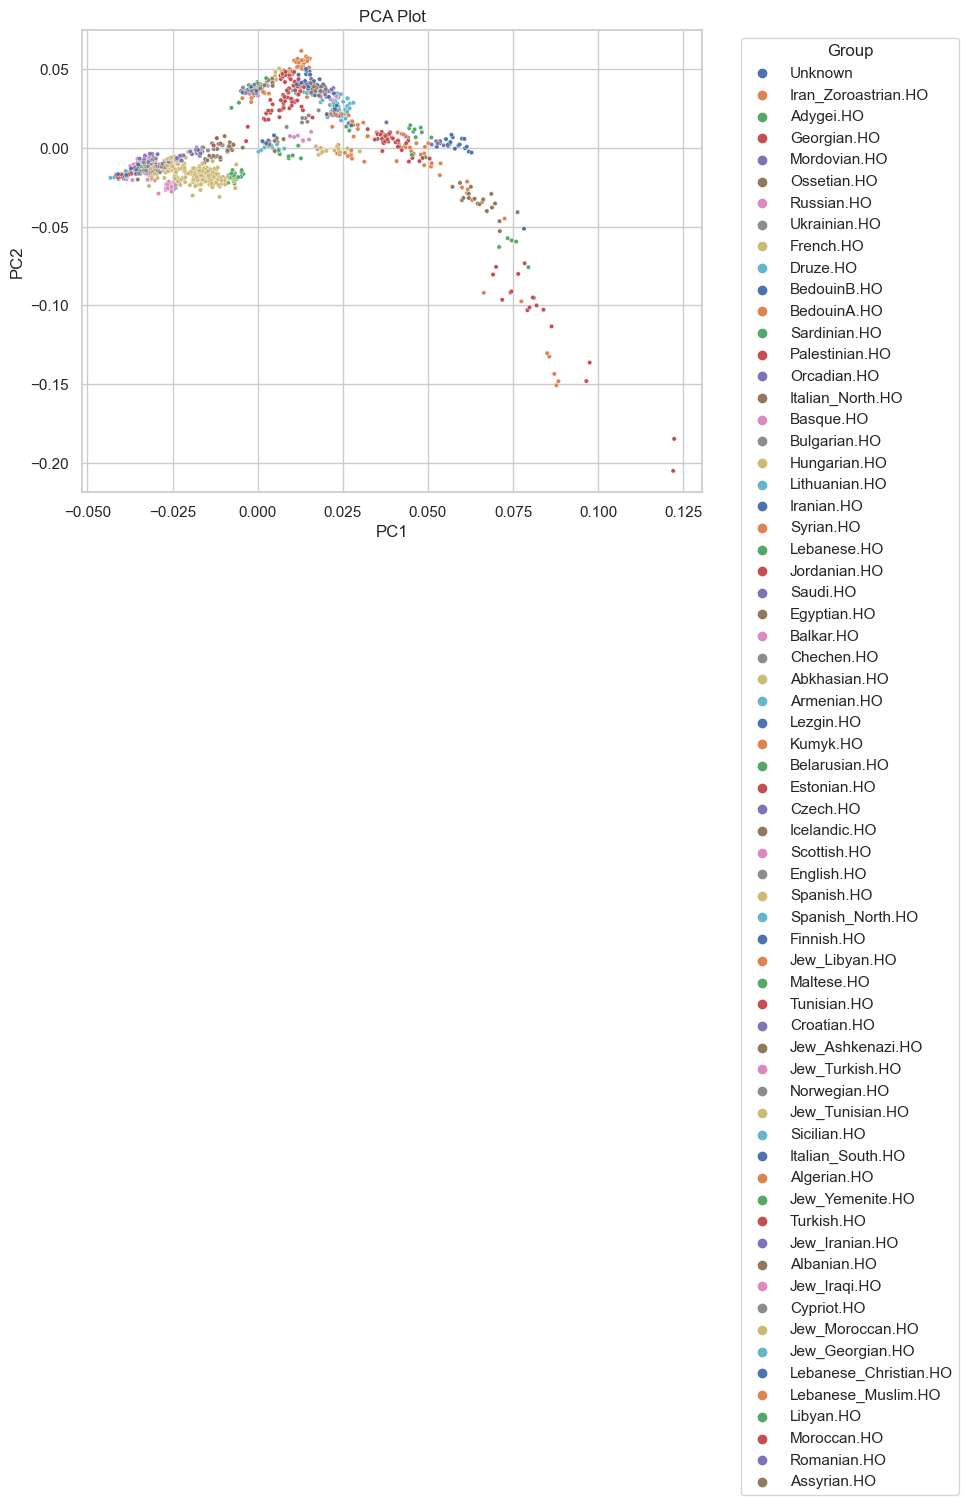

In [6]:
# Set the style for the plots
sns.set(style="whitegrid")

# Function to plot a basic PCA scatter plot from the dataframe
def plot_pca(df, pc1='PC1', pc2='PC2', title='PCA Plot'):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[pc1], y=df[pc2], hue=df['Group'], palette="deep", s=10)
    plt.title(title)
    plt.xlabel(pc1)
    plt.ylabel(pc2)
    plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Sample plot call for PCA data if available
plot_pca(df_res)  # Uncomment when you have the PCA dataframe available



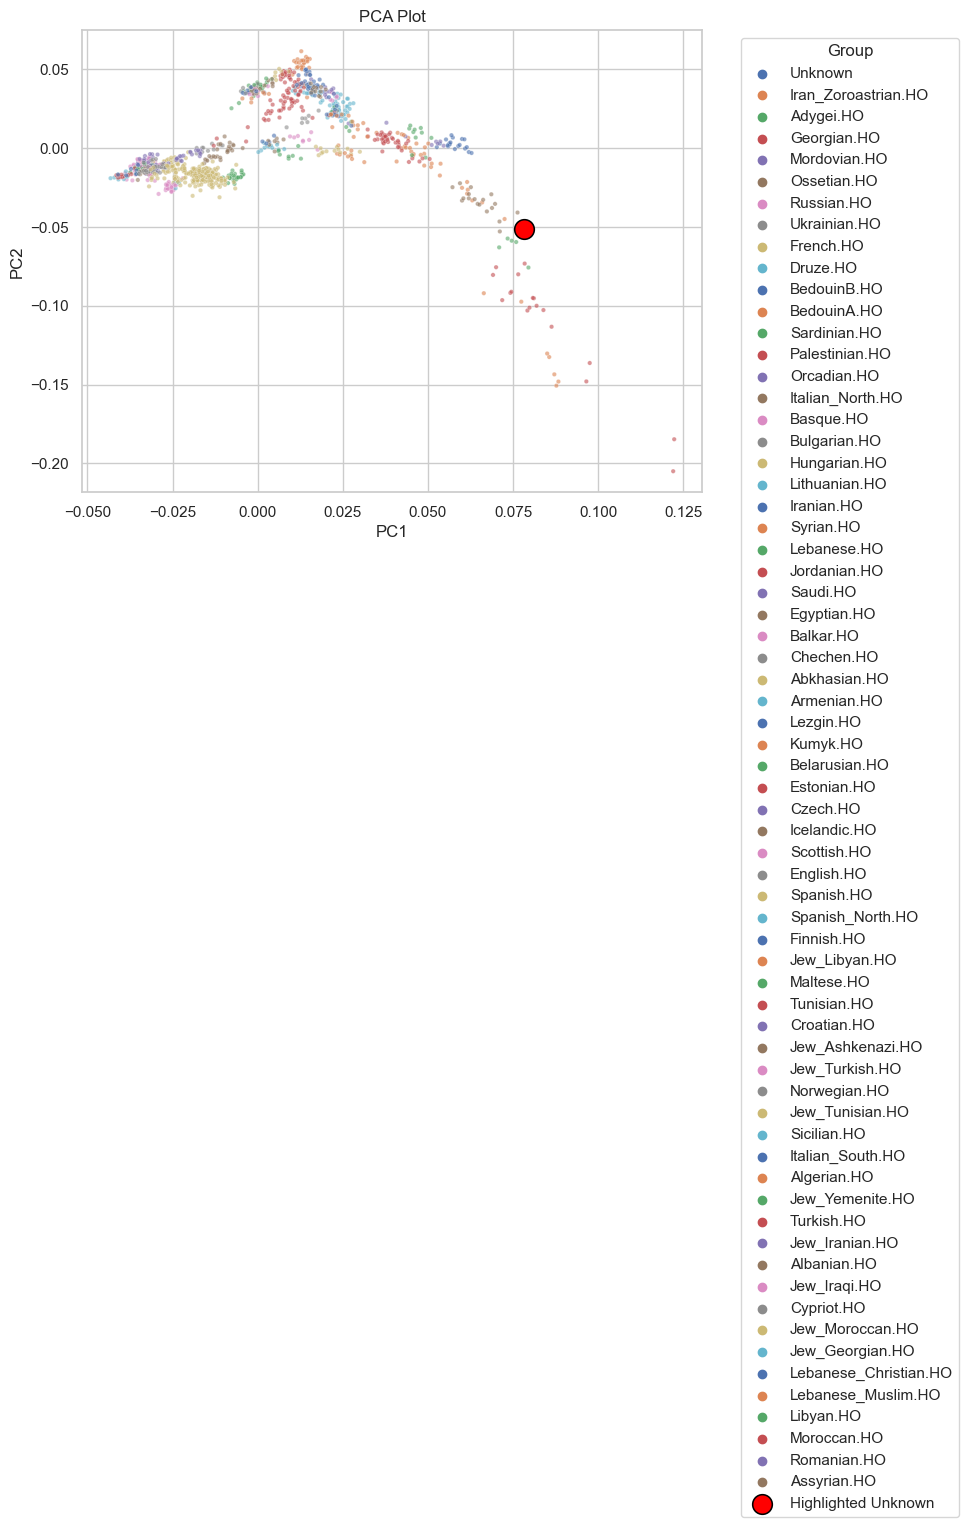

In [7]:
# Function to plot PCA scatter plot and highlight samples where group is 'Unknown'
def plot_pca_highlight_unknown(df, pc1='PC1', pc2='PC2', title='PCA Plot'):
    # Create the base scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[pc1], y=df[pc2], hue=df['Group'], palette="deep", s=10, alpha=0.6)
    
    # Highlight points where the group is 'Unknown'
    highlighted = df[df['Group'] == 'Unknown']
    sns.scatterplot(x=highlighted[pc1], y=highlighted[pc2], color='red', s=200, label='Highlighted Unknown', edgecolor='black')

    plt.title(title)
    plt.xlabel(pc1)
    plt.ylabel(pc2)
    plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Call the function to plot with 'Unknown' group highlighted
# Assuming df_res contains the relevant PCA data
plot_pca_highlight_unknown(df_res)  # Uncomment if df_res is loaded correctly with PCA data



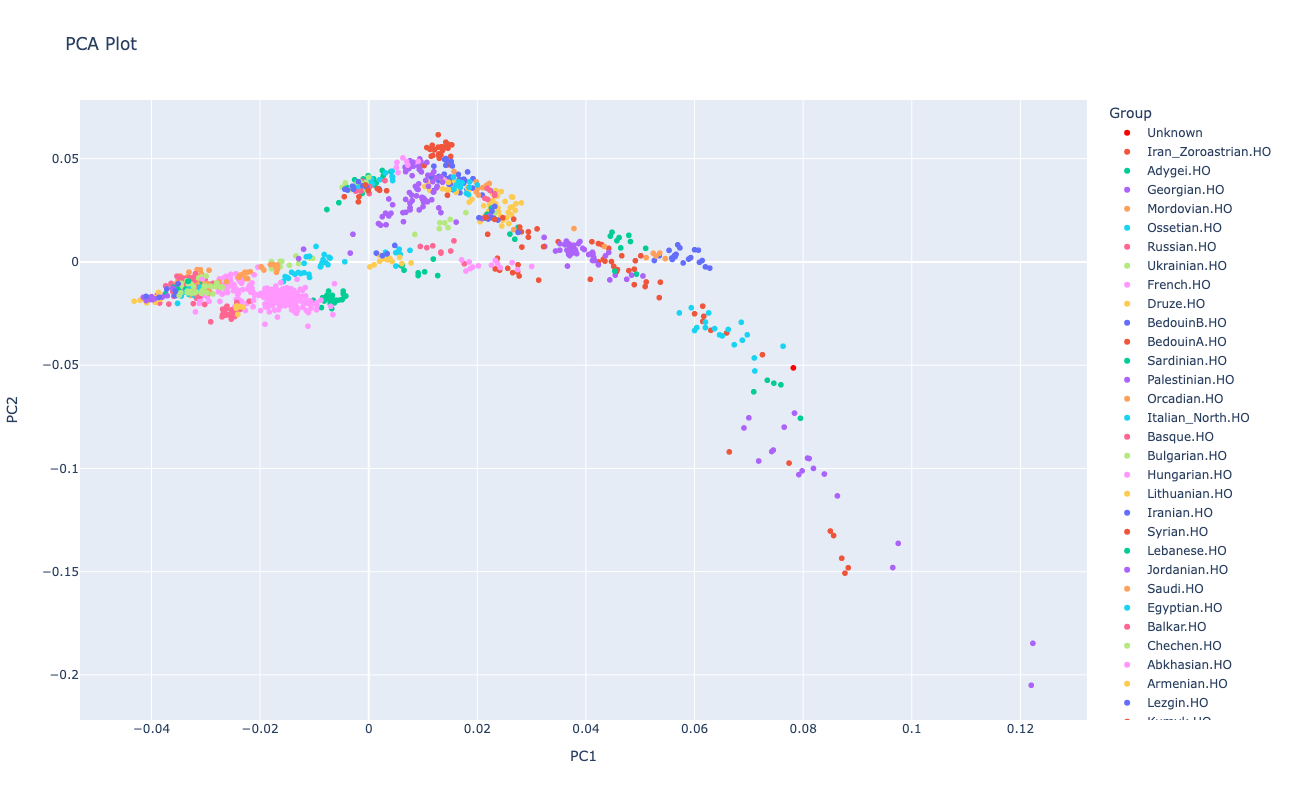

In [8]:
import plotly.express as px
import pandas as pd

# Function to plot interactive PCA plot and highlight samples where group is 'Unknown'
def plot_interactive_pca(df, pc1='PC1', pc2='PC2', title='PCA Plot', width=800, height=600):
    # Create the interactive scatter plot using plotly
    fig = px.scatter(df, x=pc1, y=pc2, color='Group', 
                     title=title,
                     color_discrete_map={'Unknown': 'red'},  # Highlight Unknown group in red
                     labels={pc1: 'PC1', pc2: 'PC2', 'Group': 'Group'},
                     hover_data=df.columns)  # You can choose columns to display in the hover tooltip
    
    # Update plot size
    fig.update_layout(width=width, height=height)
    
    # Show the plot
    fig.show()

# Assuming df_res contains the relevant PCA data
# Example usage (make sure df_res is loaded correctly with PCA data):
plot_interactive_pca(df_res, width=1000, height=800)  # Change size here


In [9]:
import plotly.express as px
import pandas as pd

# Function to plot and save interactive PCA plot
def plot_interactive_pca(df, pc1='PC1', pc2='PC2', title='PCA Plot', width=800, height=600, output_file='pca_plot.html'):
    # Create the interactive scatter plot
    fig = px.scatter(df, x=pc1, y=pc2, color='Group', 
                     title=title,
                     color_discrete_map={'sample_1948': 'red'},  # Highlight sample_1948 in red
                     labels={pc1: 'PC1', pc2: 'PC2', 'Group': 'Group'},
                     hover_data=df.columns)
    
    # Update plot size
    fig.update_layout(width=width, height=height)
    
    # Save to HTML
    fig.write_html(output_file)
    print(f"Plot saved to {output_file}")

# Replace 'Unknown' with 'sample_1948' in Group column
df_res['Group'] = df_res['Group'].replace('Unknown', 'sample_1948')

# Plot and save
plot_interactive_pca(df_res, width=1000, height=800, output_file='pca_interactive_plot.html')


Plot saved to pca_interactive_plot.html


/var/folders/pm/ksrn_2cd4fg8rb778prr67xr0000gn/T/ipykernel_15475/4107773343.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [10]:
df_res.Group.unique()

arab_pops = ['Palestinian.HO','Jordanian.HO','Lebanese.HO','Syrian.HO','Lebanese_Christian.HO','Lebanese_Muslim.HO','Iraqi.HO','Yemenite.HO', 'Unknown',
            'Lebanese_Christian.HO', 'Jew_Yemenite.HO','Jew_Iranian.HO', 'BedouinB.HO', 'BedouinA.HO']

In [11]:
df_res.Group.unique()

array(['sample_1948', 'Iran_Zoroastrian.HO', 'Adygei.HO', 'Georgian.HO',
       'Mordovian.HO', 'Ossetian.HO', 'Russian.HO', 'Ukrainian.HO',
       'French.HO', 'Druze.HO', 'BedouinB.HO', 'BedouinA.HO',
       'Sardinian.HO', 'Palestinian.HO', 'Orcadian.HO',
       'Italian_North.HO', 'Basque.HO', 'Bulgarian.HO', 'Hungarian.HO',
       'Lithuanian.HO', 'Iranian.HO', 'Syrian.HO', 'Lebanese.HO',
       'Jordanian.HO', 'Saudi.HO', 'Egyptian.HO', 'Balkar.HO',
       'Chechen.HO', 'Abkhasian.HO', 'Armenian.HO', 'Lezgin.HO',
       'Kumyk.HO', 'Belarusian.HO', 'Estonian.HO', 'Czech.HO',
       'Icelandic.HO', 'Scottish.HO', 'English.HO', 'Spanish.HO',
       'Spanish_North.HO', 'Finnish.HO', 'Jew_Libyan.HO', 'Maltese.HO',
       'Tunisian.HO', 'Croatian.HO', 'Jew_Ashkenazi.HO', 'Jew_Turkish.HO',
       'Norwegian.HO', 'Jew_Tunisian.HO', 'Sicilian.HO',
       'Italian_South.HO', 'Algerian.HO', 'Jew_Yemenite.HO', 'Turkish.HO',
       'Jew_Iranian.HO', 'Albanian.HO', 'Jew_Iraqi.HO', 'Cypriot.HO

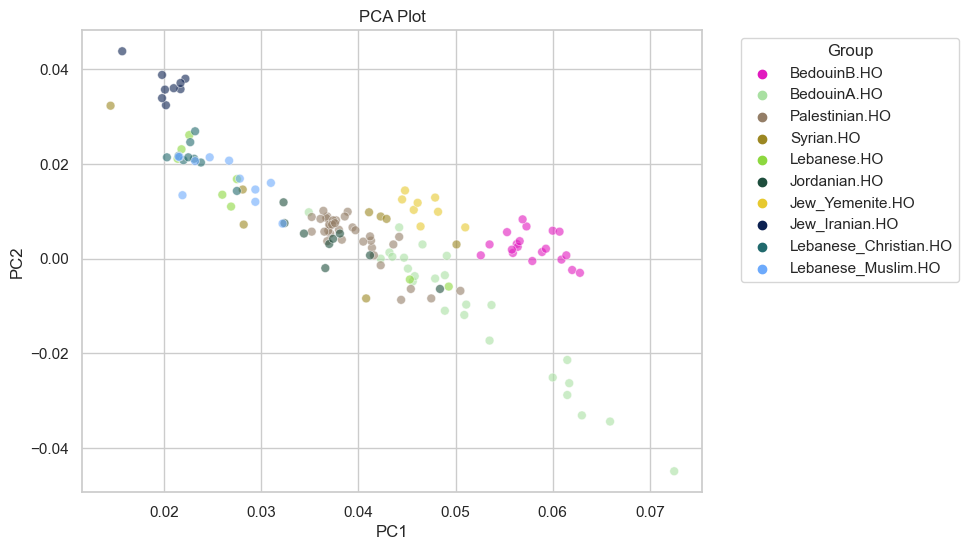

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Function to generate a random color map of n colors
def generate_random_colors(n):
    colors = []
    for _ in range(n):
        colors.append(np.random.rand(3,))  # Random RGB color
    return colors

# Function to plot PCA and highlight 'Unknown' group with random colors for each group
def plot_pca_highlight_unknown(df, pc1='PC1', pc2='PC2', title='PCA Plot'):
    # Generate a random color map for each group
    unique_groups = df['Group'].unique()
    random_colors = generate_random_colors(len(unique_groups))
    color_map = dict(zip(unique_groups, random_colors))
    
    # Create the base scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[pc1], y=df[pc2], hue=df['Group'], palette=color_map, s=40, alpha=0.6)
    
    # Highlight points where the group is 'Unknown'
    highlighted = df[df['Group'] == 'Unknown']
    sns.scatterplot(x=highlighted[pc1], y=highlighted[pc2], color='red', s=200, label='Highlighted Unknown', edgecolor='black')
    
    # Add group names at the center of each cluster
    for group in df['Group'].unique():
        group_data = df[df['Group'] == group]
        center_x = group_data[pc1].mean()
        center_y = group_data[pc2].mean()
        
        # Add the group name in the center of the cluster with a white background for better visibility
        # plt.text(center_x, center_y, group, fontsize=12, weight='bold', 
        #          ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    plt.title(title)
    plt.xlabel(pc1)
    plt.ylabel(pc2)
    plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Example usage (make sure df_res is loaded with PCA data):
plot_pca_highlight_unknown(df_res[df_res.Group.isin(arab_pops)])


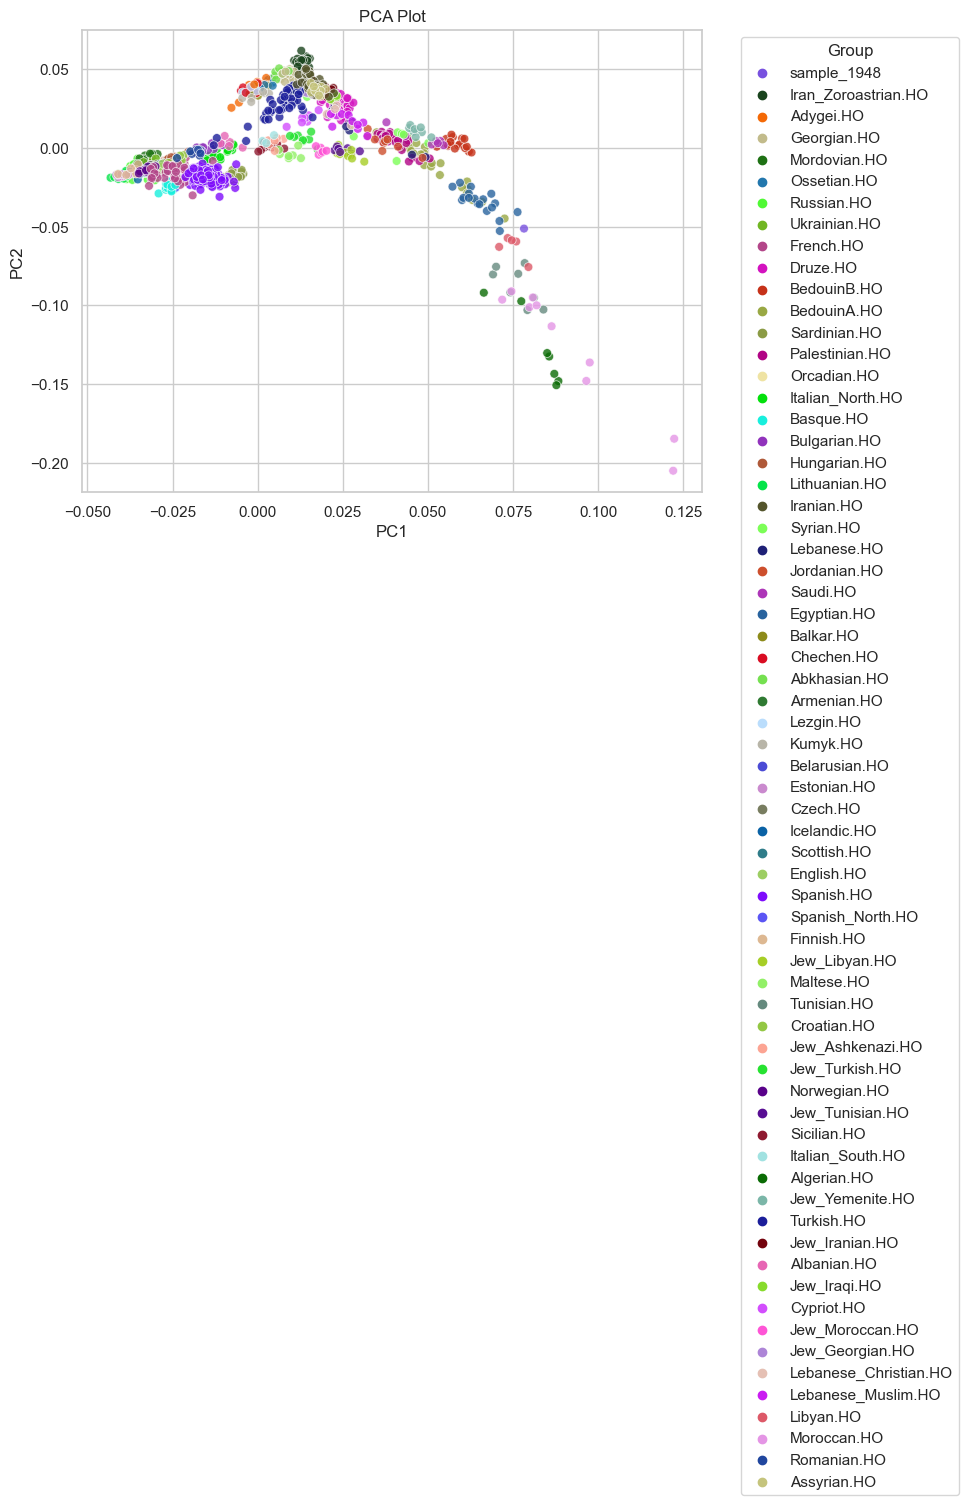

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Function to generate a random color map of n colors
def generate_random_colors(n):
    colors = []
    for _ in range(n):
        colors.append(np.random.rand(3,))  # Random RGB color
    return colors

# Function to plot PCA and highlight 'Unknown' group with random colors for each group
def plot_pca_highlight_unknown(df, pc1='PC1', pc2='PC2', title='PCA Plot'):
    # Generate a random color map for each group
    unique_groups = df['Group'].unique()
    random_colors = generate_random_colors(len(unique_groups))
    color_map = dict(zip(unique_groups, random_colors))
    
    # Create the base scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[pc1], y=df[pc2], hue=df['Group'], palette=color_map, s=40, alpha=0.8)
    
    # Highlight points where the group is 'Unknown'
    highlighted = df[df['Group'] == 'Unknown']
    sns.scatterplot(x=highlighted[pc1], y=highlighted[pc2], color='red', s=200, label='Highlighted Unknown', edgecolor='black')
    
    # Add group names at the center of each cluster
    for group in df['Group'].unique():
        group_data = df[df['Group'] == group]
        center_x = group_data[pc1].mean()
        center_y = group_data[pc2].mean()
        
        # Add the group name in the center of the cluster with a white background for better visibility
#         plt.text(center_x, center_y, group, fontsize=12, weight='bold', 
#                  ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    plt.title(title)
    plt.xlabel(pc1)
    plt.ylabel(pc2)
    
    # Remove 'Unknown' from the legend
    handles, labels = plt.gca().get_legend_handles_labels()
    new_handles = [handle for handle, label in zip(handles, labels) if label != 'Unknown']
    new_labels = [label for label in labels if label != 'Unknown']
    plt.legend(new_handles, new_labels, title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.show()
    
plot_pca_highlight_unknown(df_res)


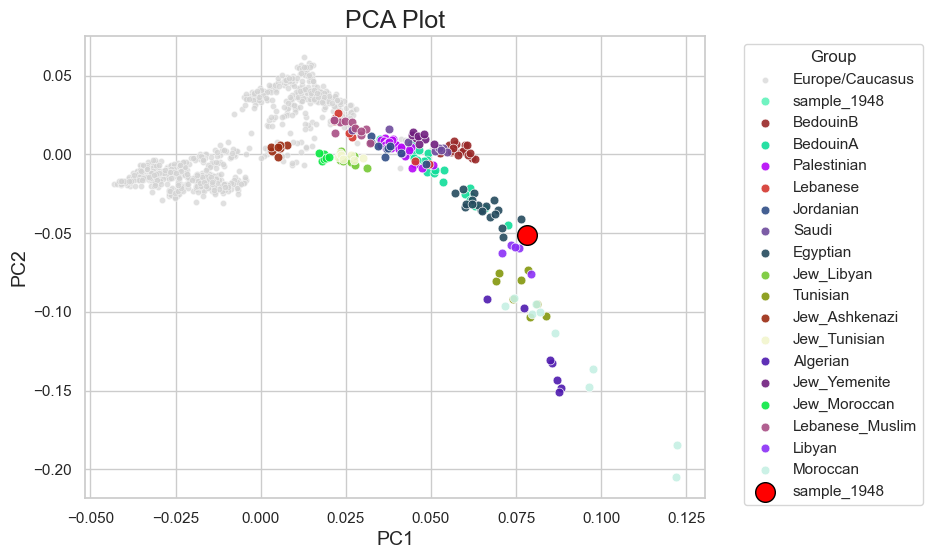

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def generate_random_colors(n):
    np.random.seed(42)  # For reproducibility
    return [np.random.rand(3,) for _ in range(n)]

def plot_pca_europe_caucasus_grey(df, pc1='PC1', pc2='PC2', title='PCA Plot'):
    # Define European groups
    european_groups = [
        'French.HO', 'Basque.HO', 'Bulgarian.HO', 'Hungarian.HO', 'Lithuanian.HO',
        'Mordovian.HO', 'Russian.HO', 'Ukrainian.HO', 'Belarusian.HO', 'Estonian.HO',
        'Czech.HO', 'Icelandic.HO', 'Scottish.HO', 'English.HO', 'Spanish.HO',
        'Spanish_North.HO', 'Finnish.HO', 'Maltese.HO', 'Croatian.HO', 
        'Italian_North.HO', 'Italian_South.HO', 'Sardinian.HO', 'Norwegian.HO',
        'Albanian.HO', 'Romanian.HO', 'Sicilian.HO', 'Orcadian.HO', 'Cypriot.HO',
    ]
    
    # Define Caucasus groups
    caucasus_groups = [
        'Adygei.HO', 'Abkhasian.HO', 'Armenian.HO', 'Balkar.HO', 'Chechen.HO',
        'Lezgin.HO', 'Kumyk.HO', 'Georgian.HO', 'Ossetian.HO', 'Iran_Zoroastrian.HO', 'Turkish.HO', 'Iranian.HO', 'Jew_Iranian.HO','Assyrian.HO',  'Jew_Turkish.HO',
        'Jew_Georgian.HO', 'Druze.HO','Syrian.HO','Lebanese_Christian.HO','Jew_Iraqi.HO',
    ]
    
    grey_groups = european_groups + caucasus_groups
    
    unique_groups = df['Group'].unique()
    non_grey_groups = [g for g in unique_groups if g not in grey_groups and g != 'Unknown']

    # Generate random colors for non-grey groups
    random_colors = generate_random_colors(len(non_grey_groups))
    color_map = dict(zip(non_grey_groups, random_colors))

    plt.figure(figsize=(8, 6))

    # Plot European + Caucasus groups in grey
    grey_df = df[df['Group'].isin(grey_groups)]
    sns.scatterplot(x=grey_df[pc1], y=grey_df[pc2], color='lightgrey', s=20, alpha=0.7, label='Europe/Caucasus')

    # Plot non-European and non-Caucasus groups in color
    for group in non_grey_groups:
        group_data = df[df['Group'] == group]
        sns.scatterplot(x=group_data[pc1], y=group_data[pc2], color=color_map[group], s=40, alpha=0.9, label=group.replace('.HO', ''))

    # Highlight 'Unknown' separately
    #highlighted = df[df['Group'] == 'Unknown']
    highlighted = df[df['Group'] == 'sample_1948']
    if not highlighted.empty:
        plt.scatter(highlighted[pc1], highlighted[pc2], color='red', s=200, edgecolor='black', label='sample_1948')

    # Add group labels at the center of each colored cluster
    # for group in non_grey_groups:
    #     group_data = df[df['Group'] == group]
    #     center_x = group_data[pc1].mean()
    #     center_y = group_data[pc2].mean()
    #     plt.text(center_x, center_y, group.replace('.HO', ''), 
    #              fontsize=10, fontweight='bold', 
    #              ha='center', va='center',
    #              bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3'))

    plt.title(title, fontsize=18)
    plt.xlabel(pc1, fontsize=14)
    plt.ylabel(pc2, fontsize=14)
    plt.grid(True)
    plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Example usage:
plot_pca_europe_caucasus_grey(df_res)


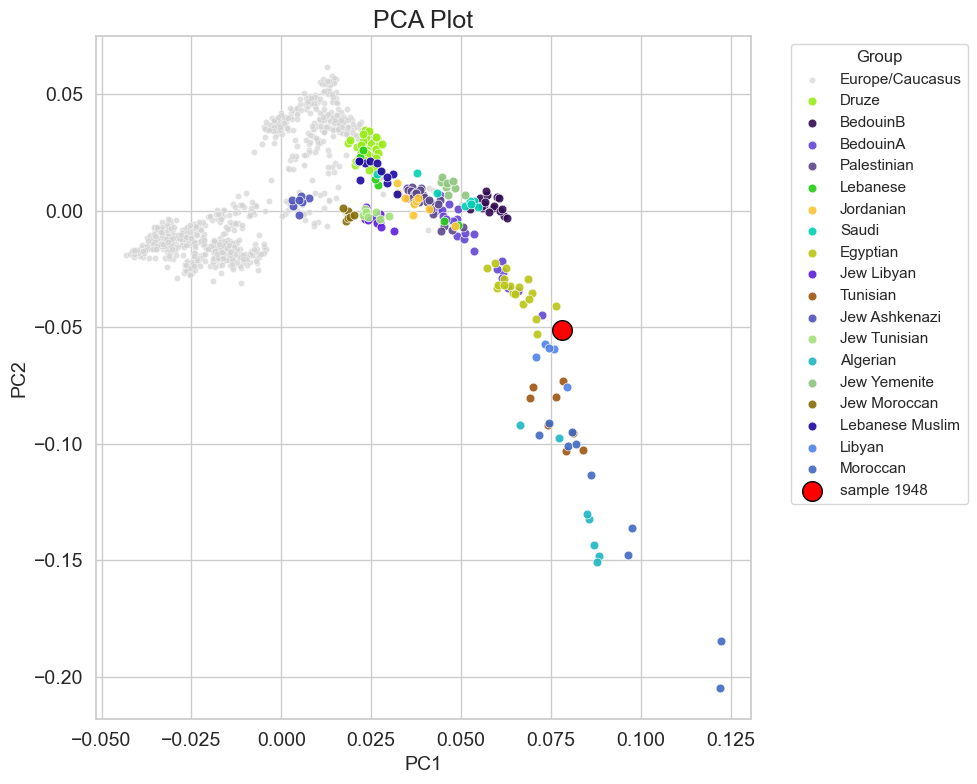

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# df_res should be your DataFrame with columns 'PC1', 'PC2', and 'Group'
# e.g.: df_res = pd.read_csv("pca_results.tsv", sep="\t")

# 1. Define the European + Caucasus groups
european_groups = [
    'French.HO', 'Basque.HO', 'Bulgarian.HO', 'Hungarian.HO', 'Lithuanian.HO',
    'Mordovian.HO', 'Russian.HO', 'Ukrainian.HO', 'Belarusian.HO', 'Estonian.HO',
    'Czech.HO', 'Icelandic.HO', 'Scottish.HO', 'English.HO', 'Spanish.HO',
    'Spanish_North.HO', 'Finnish.HO', 'Maltese.HO', 'Croatian.HO',
    'Italian_North.HO', 'Italian_South.HO', 'Sardinian.HO', 'Norwegian.HO',
    'Albanian.HO', 'Romanian.HO', 'Sicilian.HO', 'Orcadian.HO', 'Cypriot.HO',
]
caucasus_groups = [
    'Adygei.HO', 'Abkhasian.HO', 'Armenian.HO', 'Balkar.HO', 'Chechen.HO',
    'Lezgin.HO', 'Kumyk.HO', 'Georgian.HO', 'Ossetian.HO',
    'Iran_Zoroastrian.HO', 'Turkish.HO', 'Iranian.HO',
    'Jew_Iranian.HO', 'Assyrian.HO', 'Jew_Turkish.HO',
    'Jew_Georgian.HO', 'Syrian.HO',
    'Lebanese_Christian.HO', 'Jew_Iraqi.HO',
]
grey_groups = set(european_groups + caucasus_groups)

# 2. Determine which groups to color randomly
unique_groups = df_res['Group'].unique()
special = 'sample_1948'
non_grey = [
    g for g in unique_groups
    if g not in grey_groups and g not in ('Unknown', special)
]

# 3. Generate fresh random colors each run
random_colors = {g: np.random.rand(3,) for g in non_grey}

# 4. Plot setup
plt.figure(figsize=(10, 8))

# 4a. Grey background
grey_df = df_res[df_res['Group'].isin(grey_groups)]
sns.scatterplot(
    x=grey_df['PC1'], y=grey_df['PC2'],
    color='lightgrey', s=20, alpha=0.7,
    label='Europe/Caucasus'
)

# 4b. Randomly colored groups
for grp in non_grey:
    grp_df = df_res[df_res['Group'] == grp]
    label = grp.replace('.HO', '').replace('_', ' ')
    sns.scatterplot(
        x=grp_df['PC1'], y=grp_df['PC2'],
        color=random_colors[grp], s=40, alpha=0.9,
        label=label
    )

# 4c. Highlight your special sample in red
highlight_df = df_res[df_res['Group'] == special]
if not highlight_df.empty:
    plt.scatter(
        highlight_df['PC1'], highlight_df['PC2'],
        color='red', s=200, edgecolor='black',
        label=special.replace('_', ' ')
    )

# 5. Annotations
plt.title('PCA Plot', fontsize=18)
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.grid(True)

#6. Rotate tick labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# 7. Legend: ensure 'Unknown' (if present) is last, and no duplicate special sample
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

# Replace underscores in any remaining labels
labels = [lbl.replace('_', ' ') for lbl in labels]

# Reorder Unknown last if present
if 'Unknown' in labels:
    ordered = [lbl for lbl in labels if lbl != 'Unknown'] + ['Unknown']
else:
    ordered = labels

# De-duplicate special sample in legend
seen = set()
final_handles, final_labels = [], []
for h, l in zip(handles, labels):
    if l.lower() == special.lower().replace('_', ' ') and l in seen:
        continue
    seen.add(l)
    if l in ordered:
        final_handles.append(h)
        final_labels.append(l)

ax.legend(final_handles, final_labels,
          title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [16]:
labels

['Europe/Caucasus',
 'Druze',
 'BedouinB',
 'BedouinA',
 'Palestinian',
 'Lebanese',
 'Jordanian',
 'Saudi',
 'Egyptian',
 'Jew Libyan',
 'Tunisian',
 'Jew Ashkenazi',
 'Jew Tunisian',
 'Algerian',
 'Jew Yemenite',
 'Jew Moroccan',
 'Lebanese Muslim',
 'Libyan',
 'Moroccan',
 'sample 1948']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# … (your df_res loading, group lists, grey_groups, special, etc.) …

# 1. Build a qualitative palette
palette = sns.color_palette("tab20", n_colors=len(non_grey))

# 2. Define a cycle of marker styles
markers = ["o", "s", "D", "^", "v", "P", "X", "<", ">", "*", "h", "H", "d", "p", "8"]

# Map each non-grey group to a (color, marker)
style_map = {
    grp: {"color": palette[i % len(palette)],
          "marker": markers[i % len(markers)]}
    for i, grp in enumerate(non_grey)
}

plt.figure(figsize=(10, 8))

# Grey background
grey_df = df_res[df_res['Group'].isin(grey_groups)]
sns.scatterplot(
    x="PC1", y="PC2",
    data=grey_df,
    color="lightgrey", s=20, alpha=0.7,
    label="Europe/Caucasus"
)

# Colored + styled groups
for grp in non_grey:
    grp_df = df_res[df_res["Group"] == grp]
    specs = style_map[grp]
    plt.scatter(
        grp_df["PC1"], grp_df["PC2"],
        color=specs["color"],
        marker=specs["marker"],
        s=40,    # slightly larger
        alpha=0.6,
        label=grp.replace(".HO", "").replace("_", " ")
    )

# Highlight special sample.
# Reviewer #2: do NOT paste an oversized marker over the sample; the reader must be
# able to verify the true position of the original data point. So we (a) draw the
# sample's actual data point at the SAME size as the reference points, and
# (b) point to it with an arrow + label placed in empty space.
highlight_df = df_res[df_res["Group"] == special]
if not highlight_df.empty:
    px, py = highlight_df["PC1"].iloc[0], highlight_df["PC2"].iloc[0]
    plt.scatter(
        px, py,
        color="red", marker="o",
        s=45, edgecolor="black", linewidth=0.8, zorder=6,
        label=special.replace("_", " ")
    )
    plt.annotate(
        "sample 1948",
        xy=(px, py), xycoords="data",
        xytext=(0.093, -0.075), textcoords="data",
        fontsize=13, fontweight="bold", color="red",
        ha="center", va="top",
        arrowprops=dict(arrowstyle="-|>", color="red", lw=2.2, shrinkB=4),
        zorder=7,
    )

#plt.title("PCA Plot", fontsize=18)
plt.xlabel("Principal Component 1", fontsize=17)
plt.ylabel("Principal Component 2", fontsize=17)
plt.ylim(-0.12, 0.055)
plt.xlim(-0.05, 0.105)
plt.grid(False)

# Build legend so 'Unknown' is last and 'sample 1948' stands out
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

# sanitize labels
labels = [lbl.replace("_", " ") for lbl in labels]

# reorder: move Unknown to end (if present)
ordered_labels = [l for l in labels if l != "Unknown"] + (["Unknown"] if "Unknown" in labels else [])

# dedupe & respect our order
seen = set()
final_handles, final_labels = [], []
for h, l in zip(handles, labels):
    if l in seen: 
        continue
    seen.add(l)
    if l in ordered_labels:
        final_handles.append(h)
        final_labels.append(l)

ax.legend(
    final_handles, final_labels,
    title="Group",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    markerscale=1.5,   # legend markers a bit bigger
    fontsize=10,
    title_fontsize=12
)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# מבטיח שכל האלמנטים (כולל המקרא החיצוני) ייכנסו לפריסה
plt.tight_layout()

# שמירה באיכות גבוהה
# הפרמטר bbox_inches='tight' קריטי כאן כדי שהמקרא שנמצא בחוץ לא ייגזר
plt.savefig('pca_plot_high_res.png', dpi=300, bbox_inches='tight')

# הצגת הגרף
plt.show()


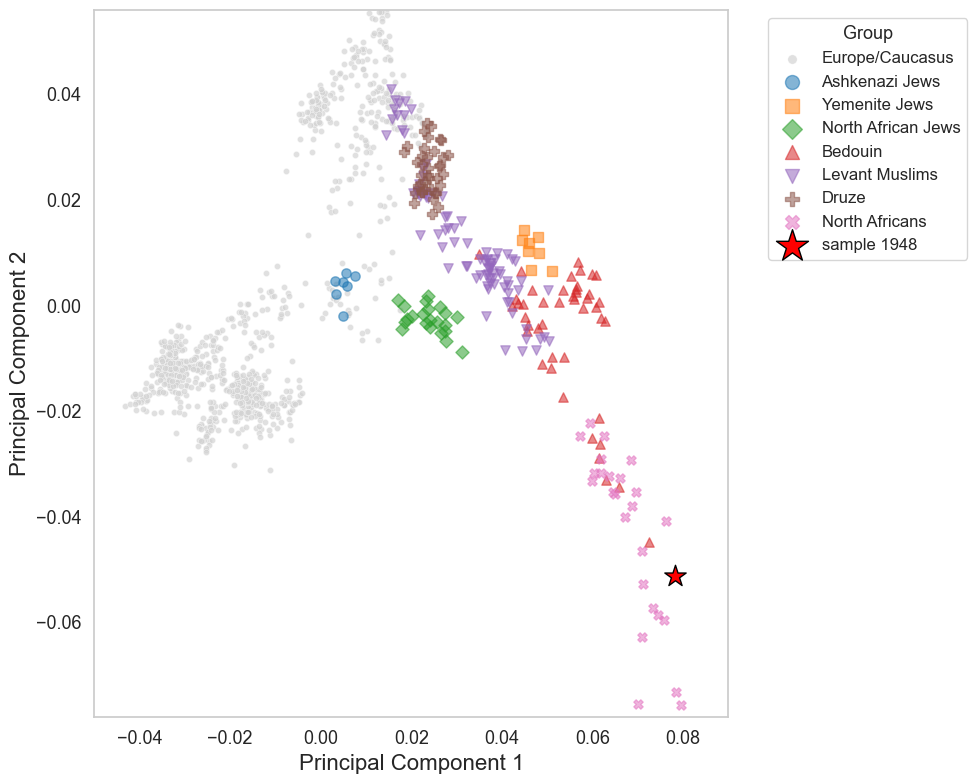

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_res.copy()

# ----------------------------
# 0) remove Saudi
# ----------------------------
df = df[df["Group"] != "Saudi.HO"].copy()

# ----------------------------
# 1) define sets (exact names)
# ----------------------------
north_africans = {
    "Egyptian.HO", "Libyan.HO", "Algerian.HO", "Tunisian.HO", "Moroccan.HO"
}

bedouins = {"BedouinA.HO", "BedouinB.HO"}

levant_muslims = {
    "Palestinian.HO", "Jordanian.HO", "Lebanese.HO", "Syrian.HO", "Assyrian.HO",
    "Lebanese_Muslim.HO", "Lebanese_Christian.HO"
}

na_jews = {"Jew_Libyan.HO", "Jew_Tunisian.HO", "Jew_Moroccan.HO"}
# אם בעתיד יהיה לך גם Jew_Algerian.HO / Jew_Egyptian.HO וכו' – תוסיפי כאן

# ----------------------------
# 2) map to slim groups
# ----------------------------
def slim_group(g):
    if g == "sample_1948":
        return "sample 1948"
    if g in north_africans:
        return "North Africans"
    if g in bedouins:
        return "Bedouin"
    if g in levant_muslims:
        return "Levant Muslims"
    if g in na_jews:
        return "North African Jews"
    if g == "Jew_Ashkenazi.HO":
        return "Ashkenazi Jews"
    if g == "Jew_Yemenite.HO":
        return "Yemenite Jews"
    if g == "Druze.HO":
        return "Druze"
    return "Europe/Caucasus"  # everything else

df["Group_slim"] = df["Group"].map(slim_group)

# ----------------------------
# 3) plot
# ----------------------------
plt.figure(figsize=(10, 8))

# grey background
grey_df = df[df["Group_slim"] == "Europe/Caucasus"]
sns.scatterplot(
    x="PC1", y="PC2",
    data=grey_df,
    color="lightgrey", s=20, alpha=0.7,
    label="Europe/Caucasus"
)

# colored groups (only the 7 you wanted)
groups_order = [
    "Ashkenazi Jews", "Yemenite Jews", "North African Jews",
    "Bedouin", "Levant Muslims", "Druze", "North Africans"
]
plot_df = df[df["Group_slim"].isin(groups_order)].copy()

palette = sns.color_palette("tab10", n_colors=len(groups_order))
markers = ["o", "s", "D", "^", "v", "P", "X"]

style_map = {
    grp: {"color": palette[i], "marker": markers[i]}
    for i, grp in enumerate(groups_order)
}

for grp in groups_order:
    gdf = plot_df[plot_df["Group_slim"] == grp]
    specs = style_map[grp]
    plt.scatter(
        gdf["PC1"], gdf["PC2"],
        color=specs["color"], marker=specs["marker"],
        s=45, alpha=0.55,
        label=grp
    )

# special sample
hdf = df[df["Group_slim"] == "sample 1948"]
if not hdf.empty:
    plt.scatter(
        hdf["PC1"], hdf["PC2"],
        color="red", marker="*", s=260,
        edgecolor="black", linewidth=1.0,
        label="sample 1948"
    )

plt.xlabel("Principal Component 1", fontsize=16)
plt.ylabel("Principal Component 2", fontsize=16)
plt.ylim(-0.078, 0.056)
plt.xlim(-0.05, 0.09)
plt.grid(False)

# clean legend order
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
order = ["Europe/Caucasus"] + groups_order + ["sample 1948"]

final_handles, final_labels = [], []
seen = set()
for o in order:
    for h, l in zip(handles, labels):
        if l == o and l not in seen:
            final_handles.append(h); final_labels.append(l); seen.add(l)

ax.legend(
    final_handles, final_labels,
    title="Group",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    markerscale=1.5,
    fontsize=12,
    title_fontsize=13
)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()


In [19]:
df_res["Group"].unique()

array(['sample_1948', 'Iran_Zoroastrian.HO', 'Adygei.HO', 'Georgian.HO',
       'Mordovian.HO', 'Ossetian.HO', 'Russian.HO', 'Ukrainian.HO',
       'French.HO', 'Druze.HO', 'BedouinB.HO', 'BedouinA.HO',
       'Sardinian.HO', 'Palestinian.HO', 'Orcadian.HO',
       'Italian_North.HO', 'Basque.HO', 'Bulgarian.HO', 'Hungarian.HO',
       'Lithuanian.HO', 'Iranian.HO', 'Syrian.HO', 'Lebanese.HO',
       'Jordanian.HO', 'Saudi.HO', 'Egyptian.HO', 'Balkar.HO',
       'Chechen.HO', 'Abkhasian.HO', 'Armenian.HO', 'Lezgin.HO',
       'Kumyk.HO', 'Belarusian.HO', 'Estonian.HO', 'Czech.HO',
       'Icelandic.HO', 'Scottish.HO', 'English.HO', 'Spanish.HO',
       'Spanish_North.HO', 'Finnish.HO', 'Jew_Libyan.HO', 'Maltese.HO',
       'Tunisian.HO', 'Croatian.HO', 'Jew_Ashkenazi.HO', 'Jew_Turkish.HO',
       'Norwegian.HO', 'Jew_Tunisian.HO', 'Sicilian.HO',
       'Italian_South.HO', 'Algerian.HO', 'Jew_Yemenite.HO', 'Turkish.HO',
       'Jew_Iranian.HO', 'Albanian.HO', 'Jew_Iraqi.HO', 'Cypriot.HO

In [20]:
european_groups = [
    'French.HO', 'Basque.HO', 'Bulgarian.HO', 'Hungarian.HO', 'Lithuanian.HO',
    'Mordovian.HO', 'Russian.HO', 'Ukrainian.HO', 'Belarusian.HO', 'Estonian.HO',
    'Czech.HO', 'Icelandic.HO', 'Scottish.HO', 'English.HO', 'Spanish.HO',
    'Spanish_North.HO', 'Finnish.HO', 'Maltese.HO', 'Croatian.HO', 
    'Italian_North.HO', 'Italian_South.HO', 'Sardinian.HO', 'Norwegian.HO',
    'Albanian.HO', 'Romanian.HO', 'Sicilian.HO', 'Orcadian.HO', 'Cypriot.HO',
    'Adygei.HO', 'Abkhasian.HO', 'Armenian.HO', 'Balkar.HO', 'Chechen.HO',
    'Lezgin.HO', 'Kumyk.HO', 'Georgian.HO', 'Ossetian.HO', 'Iran_Zoroastrian.HO', 'Turkish.HO', 'Iranian.HO', 'Jew_Iranian.HO','Assyrian.HO',  'Jew_Turkish.HO'
]


[g for g in df_res['Group'].unique() if g not in european_groups]

['sample_1948',
 'Druze.HO',
 'BedouinB.HO',
 'BedouinA.HO',
 'Palestinian.HO',
 'Syrian.HO',
 'Lebanese.HO',
 'Jordanian.HO',
 'Saudi.HO',
 'Egyptian.HO',
 'Jew_Libyan.HO',
 'Tunisian.HO',
 'Jew_Ashkenazi.HO',
 'Jew_Tunisian.HO',
 'Algerian.HO',
 'Jew_Yemenite.HO',
 'Jew_Iraqi.HO',
 'Jew_Moroccan.HO',
 'Jew_Georgian.HO',
 'Lebanese_Christian.HO',
 'Lebanese_Muslim.HO',
 'Libyan.HO',
 'Moroccan.HO']

In [21]:
import pandas as pd

fam = pd.read_csv("merged_pruned_subset_keep.fam", delim_whitespace=True, header=None)
meta = pd.read_csv("pop_labels.tsv", sep="\t", names=["IID", "Sex", "Pop"])
ind2pop = fam[[1]].merge(meta[["IID", "Pop"]], left_on=1, right_on="IID", how="left")
ind2pop[[1, "Pop"]].to_csv("admixture_runs/ind2pop.txt", sep="\t", header=False, index=False)


In [22]:
ind2pop

,1,IID,Pop
0,JD206,JD206,Unknown
1,SH001.HO,SH001.HO,Iran_Zoroastrian.HO
2,SH003.HO,SH003.HO,Iran_Zoroastrian.HO
3,SH004.HO,SH004.HO,Iran_Zoroastrian.HO
4,SH005.HO,SH005.HO,Iran_Zoroastrian.HO
...,...,...,...
405,PV034.HO,PV034.HO,Iranian.HO
406,PV035.HO,PV035.HO,Iranian.HO
407,PV036.HO,PV036.HO,Iranian.HO
408,PV037.HO,PV037.HO,Iranian.HO
